In [ ]:
!pip install --upgrade pip
!pip install toml torch torchinfo optuna
!pip install git+https://github.com/CSTCloudOps/EasyTSAD.git

!git clone https://github.com/CSTCloudOps/KAN-AD.git
!git clone https://github.com/CSTCloudOps/datasets.git
!mv datasets KAN-AD/datasets

%cd KAN-AD


  Cloning https://github.com/CSTCloudOps/EasyTSAD.git to /tmp/pip-req-build-44mxkgar
  Running command git clone --filter=blob:none --quiet https://github.com/CSTCloudOps/EasyTSAD.git /tmp/pip-req-build-44mxkgar
  Resolved https://github.com/CSTCloudOps/EasyTSAD.git to commit b5ab2098fb728246de02a63f4b7c133661563eec
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
fatal: destination path 'KAN-AD' already exists and is not an empty directory.
fatal: destination path 'datasets' already exists and is not an empty directory.
/content/KAN-AD


In [ ]:
import sys
import os

project_path = os.getcwd()  # should already be /content/KAN-AD
if project_path not in sys.path:
    sys.path.append(project_path)

print("🟢 Paths configured.")
print("Current working directory:", project_path)
print("Repo contents:", os.listdir(project_path))


🟢 Paths configured.
Current working directory: /content/KAN-AD
Repo contents: ['pyproject.toml', 'README.md', 'kanad', '.gitignore', 'run_exp.py', '.python-version', 'prepare_env.sh', 'LICENSE', 'uv.lock', 'datasets', '.git']


In [ ]:
# Fix EasyTSAD TSData import issues (trailing comma + Chinese comma)
!sed -i 's/TSData、/TSData/g; s/TSData,*/TSData/g' \
    /usr/local/lib/python3.12/dist-packages/EasyTSAD/DataFactory/__init__.py

# Show corrected file
!cat /usr/local/lib/python3.12/dist-packages/EasyTSAD/DataFactory/__init__.py


from .TSData import TSData
from .MTSData import MTSData


In [ ]:
import os, json
import numpy as np

# Paths
src = "/content/KAN-AD/datasets/MTS/SWaT/AllInOne"
dst_root = "/content/KAN-AD/datasets/UTS/SWaT_CI"

# Load data
train = np.load(os.path.join(src, "train.npy"))      # (T_train, D)
test  = np.load(os.path.join(src, "test.npy"))       # (T_test, D)
train_label = np.load(os.path.join(src, "train_label.npy"))
test_label  = np.load(os.path.join(src, "test_label.npy"))

# Basic checks
assert train.ndim == 2 and test.ndim == 2
Ttr, D = train.shape
Tte, D2 = test.shape
assert D == D2

# Convert labels to time-wise anomaly labels
def to_time_labels(y):
    y = np.asarray(y)
    if y.ndim == 1:
        return (y != 0).astype(np.int64)
    if y.ndim == 2:
        return (y.sum(axis=1) != 0).astype(np.int64)
    raise ValueError("Unsupported label shape")

train_y = to_time_labels(train_label)
test_y  = to_time_labels(test_label)

# KAN-AD preprocessing: differencing + normalization
def preprocess(x):
    x = np.diff(x)  # first-order differencing
    x = (x - x.mean()) / (x.std() + 1e-8)  # z-score normalization
    return x.astype(np.float32)

# Create destination
os.makedirs(dst_root, exist_ok=True)

for j in range(D):
    curve = f"channel_{j:03d}"
    out = os.path.join(dst_root, curve)
    os.makedirs(out, exist_ok=True)

    # Raw signals
    tr_raw = train[:, j]
    te_raw = test[:, j]

    # Apply preprocessing
    tr = preprocess(tr_raw)
    te = preprocess(te_raw)

    # Align labels after differencing (shift by 1)
    train_y_proc = train_y[1:]
    test_y_proc  = test_y[1:]

    # Timestamps (after diff)
    tr_ts = np.arange(len(tr), dtype=np.int64)
    te_ts = np.arange(len(te), dtype=np.int64)

    # Save files
    np.save(os.path.join(out, "train.npy"), tr)
    np.save(os.path.join(out, "test.npy"), te)
    np.save(os.path.join(out, "train_label.npy"), train_y_proc)
    np.save(os.path.join(out, "test_label.npy"), test_y_proc)
    np.save(os.path.join(out, "train_timestamp.npy"), tr_ts)
    np.save(os.path.join(out, "test_timestamp.npy"), te_ts)

    # Metadata
    info = {
        "dataset": "SWaT_CI",
        "curve": curve,
        "type": "UTS",
        "length": int(len(tr) + len(te)),
        "train_length": int(len(tr)),
        "test_length": int(len(te)),
        "feature_dim": 1
    }

    with open(os.path.join(out, "info.json"), "w") as f:
        json.dump(info, f, indent=2)

print("✅ SWaT converted to channel-independent UTS (with correct preprocessing)")
print("Total channels:", D)
print("Example files:", os.listdir(os.path.join(dst_root, "channel_000")))

✅ SWaT converted to channel-independent UTS (with correct preprocessing)
Total channels: 51
Example files: ['info.json', 'test.npy', 'train_label.npy', 'train.npy', 'train_timestamp.npy', 'test_timestamp.npy', 'test_label.npy']


Total channels found: 51
First 5 channels: ['channel_000', 'channel_001', 'channel_002', 'channel_003', 'channel_004']
Using: /content/KAN-AD/datasets/UTS/SWaT_CI/channel_000
Files: ['info.json', 'test.npy', 'test_label.npy', 'test_timestamp.npy', 'train.npy', 'train_label.npy', 'train_timestamp.npy']

TRAIN HEAD:


,timestamp,value,label
0,0,0.838854,0
1,1,0.155776,0
2,2,-1.006553,0
3,3,-0.611122,0
4,4,-0.407429,0



TRAIN INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 473398 entries, 0 to 473397
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   timestamp  473398 non-null  int64  
 1   value      473398 non-null  float32
 2   label      473398 non-null  int64  
dtypes: float32(1), int64(2)
memory usage: 9.0 MB

STATISTICS (train):


,timestamp,value,label
count,473398.000000,4.733980e+05,473398.0
mean,236698.500000,1.933949e-09,0.0
std,136658.375704,9.999098e-01,0.0
min,0.000000,-2.917887e+01,0.0
25%,118349.250000,-5.152619e-01,0.0
50%,236698.500000,1.658004e-05,0.0
75%,355047.750000,1.658004e-05,0.0
max,473397.000000,2.623104e+01,0.0



Label distribution (train):
label
0    473398
Name: count, dtype: int64


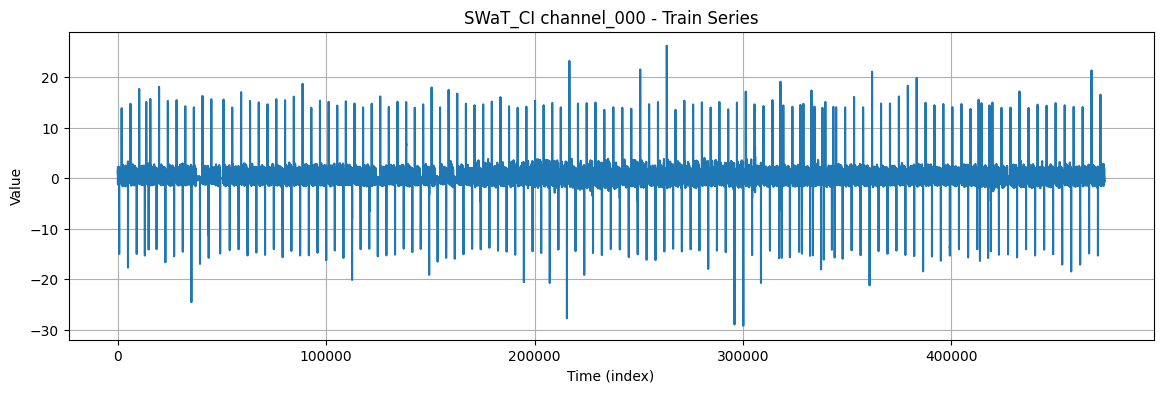

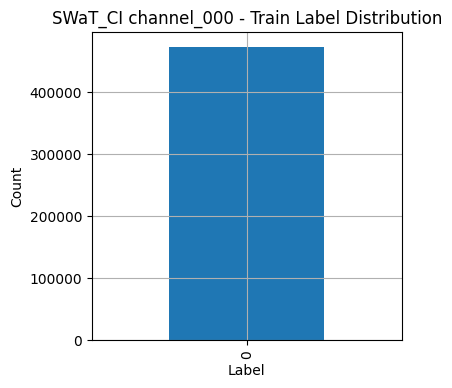


EDA complete.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Explore the channel-independent UTS dataset (paper-style)
base_dir = "/content/KAN-AD/datasets/UTS/SWaT_CI"

channels = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
print("Total channels found:", len(channels))
print("First 5 channels:", channels[:5])

data_path = os.path.join(base_dir, channels[0])  # channel_000
print("Using:", data_path)
print("Files:", sorted(os.listdir(data_path)))

train = np.load(os.path.join(data_path, "train.npy"))
train_label = np.load(os.path.join(data_path, "train_label.npy"))
train_ts = np.load(os.path.join(data_path, "train_timestamp.npy"))

test = np.load(os.path.join(data_path, "test.npy"))
test_label = np.load(os.path.join(data_path, "test_label.npy"))
test_ts = np.load(os.path.join(data_path, "test_timestamp.npy"))

df_train = pd.DataFrame({"timestamp": train_ts, "value": train, "label": train_label})
df_test  = pd.DataFrame({"timestamp": test_ts,  "value": test,  "label": test_label})

print("\nTRAIN HEAD:")
display(df_train.head())

print("\nTRAIN INFO:")
df_train.info()

print("\nSTATISTICS (train):")
display(df_train.describe())

print("\nLabel distribution (train):")
print(df_train["label"].value_counts())

# PLOTS
plt.figure(figsize=(14, 4))
plt.plot(df_train["timestamp"], df_train["value"])
plt.title(f"SWaT_CI {channels[0]} - Train Series")
plt.xlabel("Time (index)")
plt.ylabel("Value")
plt.grid(True)
plt.show()

plt.figure(figsize=(4, 4))
df_train["label"].value_counts().plot(kind="bar")
plt.title(f"SWaT_CI {channels[0]} - Train Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.grid(True)
plt.show()

print("\nEDA complete.")


In [ ]:
import sys
sys.path.insert(0, "/content/KAN-AD")  # safer than append

# Reproducibility (important)
import torch, numpy as np, random
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

from EasyTSAD.Controller import TSADController
from kanad import KANAD  # registers method

gctrl = TSADController()

gctrl.set_dataset(
    dataset_type="UTS",
    dirname="datasets",
    datasets=["SWaT"],
)

print("🚀 Starting KAN-AD training on SWaT_CI...")

gctrl.run_exps(
    method="KANAD",
    training_schema="naive",   # ✅ correct (do NOT change)
    cfg_path="kanad/config.toml",
)

print("✅ Training finished.")

(2026-04-24 15:12:57,436) [INFO]: 
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚══════╝   ╚═╝          ╚═╝   ╚══════╝╚═╝  ╚═╝╚═════╝ 
                                                                      
                         
INFO:logger:
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚═════

🚀 Starting KAN-AD training on SWaT_CI...


(2026-04-24 15:12:58,154) [INFO]:     [KANAD] handling dataset SWaT_CI | curve channel_018 
INFO:logger:    [KANAD] handling dataset SWaT_CI | curve channel_018 


=== Using CUDA ===


Validation Epoch [2/100]: 100%|██████████| 93/93 [00:00<00:00, 103.98it/s, avg_loss=0.464, loss=0.408]


...

EarlyStopping counter: 2 out of 3


Validation Epoch [5/100]: 100%|██████████| 93/93 [00:01<00:00, 63.54it/s, avg_loss=0.421, loss=0.000104]


EarlyStopping counter: 3 out of 3
   Early stopping<<<


Testing: : 100%|██████████| 440/440 [00:06<00:00, 67.91it/s]


✅ Training finished.


In [ ]:
method = "KANAD"
training_schema = "naive"

from EasyTSAD.Evaluations.Protocols import (
    EventF1PA,
    PointF1PA,
    PointKthF1PA,
    PointAuprcPA,
)

gctrl.set_evals(
    [
        PointF1PA(),                  # Best F1 (paper metric)
        EventF1PA(mode="squeeze"),
        PointKthF1PA(k=5),
        PointAuprcPA(),
    ]
)

gctrl.do_evals(method=method, training_schema=training_schema)

print("✅ Evaluation completed")

(2026-04-24 16:48:16,438) [INFO]: Register evaluations
INFO:logger:Register evaluations
(2026-04-24 16:48:16,439) [INFO]: Perform evaluations. Method[KANAD], Schema[naive].
INFO:logger:Perform evaluations. Method[KANAD], Schema[naive].
(2026-04-24 16:48:16,441) [INFO]:     [Load Data (All)] DataSets: SWaT_CI 
INFO:logger:    [Load Data (All)] DataSets: SWaT_CI 
(2026-04-24 16:48:16,672) [INFO]:     [KANAD] Eval dataset SWaT_CI <<<
INFO:logger:    [KANAD] Eval dataset SWaT_CI <<<
(2026-04-24 16:48:16,674) [INFO]:         [SWaT_CI] Using default margins (0, 5)
INFO:logger:        [SWaT_CI] Using default margins (0, 5)


✅ Evaluation completed


In [ ]:
import json

avg_path = "/content/KAN-AD/Results/Evals/KANAD/naive/SWaT_CI/avg.json"
all_path = "/content/KAN-AD/Results/Evals/KANAD/naive/SWaT_CI/all.json"

with open(avg_path, "r") as f:
    avg = json.load(f)

with open(all_path, "r") as f:
    all_scores = json.load(f)

print("=== AVERAGE RESULTS (global metrics) ===")
for k, v in avg.items():
    print(f"{k}: {v}")

print("\n=== PER-SERIES RESULTS ===")
print("Number of channels:", len(all_scores))
print("Example entry (first channel):")
print(list(all_scores.items())[0])


=== AVERAGE RESULTS (global metrics) ===
best f1 under pa: {'f1': 0.7415187960156479, 'precision': 0.7304952621287961, 'recall': 0.8958539982165575}
event-based f1 under pa with mode squeeze: {'f1': 0.12025088923531836, 'precision': 0.30512501980187345, 'recall': 0.16526610644257703}
best f1 under 5-delay pa: {'f1': 0.45471771389211485, 'precision': 0.3759739657774532, 'recall': 0.837680294396757}
point-based auprc pa: 0.6933094499241761

=== PER-SERIES RESULTS ===
Number of channels: 51
Example entry (first channel):
('channel_000', {'best f1 under pa': {'f1': 0.9585448315456603, 'precision': 0.9573147423412273, 'recall': 0.9597780859916782, 'threshold': 2.879694938659668}, 'event-based f1 under pa with mode squeeze': {'f1': 0.061403508771929564, 'precision': 0.03626943005181347, 'recall': 0.2, 'threshold': 10.540572166442871}, 'best f1 under 5-delay pa': {'f1': 0.6494993078548351, 'precision': 0.5836497752171446, 'recall': 0.7320972333746989, 'threshold': 1.045570731163025}, 'point-b